### Forest Fire Risk And Prediction Model
#### By : Shivam Singh

In [1]:
# Librarys

# Import manipulation librarys
import numpy as np
import pandas as pd

# Import visualization librarys
import matplotlib.pyplot as plt
import seaborn as sns

# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Data Ingestion 
df = pd.read_csv(r'C:\15Days15Project\Forest-Fire-Risk-and-Impact-Prediction-Model\data\raw\forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [4]:
# EDA and # preprocessing
from collections import OrderedDict

#Step 2 : descriptive stats
def descriptive_stats():
    numerical_col = df.select_dtypes(exclude = 'object').columns
    categorica_col = df.select_dtypes(include = 'object').columns
    num_stats = []
    cat_stats = []
    data_info = []

    for i in numerical_col:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        LF = Q1 - 1.5*IQR
        UF = Q3 + 1.5*IQR

        outlier_count = len(df[(df[i] < LF) | (df[i] > UF)])
        outlier_percentage = outlier_count / len(df[i]) * 100

        numerical_stats = OrderedDict({
            "Feature " : i ,
            "Q1" : Q1,
            "Q3" : Q3,
            "IQR" : IQR,
            "LF" : LF,
            "UF" : UF,
            "Mean" : df[i].mean(),
            "Median" : df[i].median(),
            "Min" : df[i].min(),
            "Max" : df[i].max(),
            "Outlier count" : outlier_count,
            "outlier percentage" : outlier_percentage,
            "standard derivation": df[i].std(),
            "variance" : df[i].var(),
            "skewness" : df[i].skew(),
            "kurtosis" : df[i].kurtosis()
        })
        num_stats.append(numerical_stats)
    numerical_stats_report = pd.DataFrame(num_stats)
    for i in categorica_col:
        categorical_stats = OrderedDict({
            "Feature" : i ,
            "Unquie count" : df[i].nunique(),
            "Value count" : df[i].value_counts(),
            "mode" : df[i].mode()
        })
        cat_stats.append(categorical_stats)
    categorical_stats_report = pd.DataFrame(cat_stats)


    for i in df.columns :
        data1 = OrderedDict({
            "Feature" : i ,
            "Missing value" : df[i].isnull().sum(),
            "Unqiue value" : df[i].nunique(),
            "value count " : df[i].value_counts().to_dict()
        })
        data_info.append(data1)
    data_info_report = pd.DataFrame(data_info)

    return categorical_stats_report,numerical_stats_report,data_info_report

categorical_stats_report,numerical_stats_report,data_info_report = descriptive_stats()

In [7]:
categorical_stats_report

,Feature,Unquie count,Value count,mode
0,month,12,month aug 184 sep 172 mar 54 jul ...,"0 aug Name: month, dtype: object"
1,day,7,day sun 95 fri 85 sat 84 mon 74 tu...,"0 sun Name: day, dtype: object"


In [8]:
numerical_stats_report

,Feature,Q1,Q3,IQR,LF,UF,Mean,Median,Min,Max,Outlier count,outlier percentage,standard derivation,variance,skewness,kurtosis
0,X,3.0,7.00,4.00,-3.000,13.000,4.669246,4.00,1.0,9.00,0,0.000000,2.313778,5.353568,0.036246,-1.172331
1,Y,4.0,5.00,1.00,2.500,6.500,4.299807,4.00,2.0,9.00,51,9.864603,1.229900,1.512655,0.417296,1.420553
2,FFMC,90.2,92.90,2.70,86.150,96.950,90.644681,91.60,18.7,96.20,53,10.251451,5.520111,30.471624,-6.575606,67.066041
3,DMC,68.6,142.40,73.80,-42.100,253.100,110.872340,108.30,1.1,291.30,17,3.288201,64.046482,4101.951889,0.547498,0.204822
4,DC,437.7,713.90,276.20,23.400,1128.200,547.940039,664.20,7.9,860.60,8,1.547389,248.066192,61536.835467,-1.100445,-0.245244
5,ISI,6.5,10.80,4.30,0.050,17.250,9.021663,8.40,0.0,56.10,23,4.448743,4.559477,20.788832,2.536325,21.458037
6,temp,15.5,22.80,7.30,4.550,33.750,18.889168,19.30,2.2,33.30,2,0.386847,5.806625,33.716898,-0.331172,0.136166
7,RH,33.0,53.00,20.00,3.000,83.000,44.288201,42.00,15.0,100.00,12,2.321083,16.317469,266.259802,0.862904,0.438183
8,wind,2.7,4.90,2.20,-0.600,8.200,4.017602,4.00,0.4,9.40,13,2.514507,1.791653,3.210019,0.571001,0.054324
9,rain,0.0,0.00,0.00,0.000,0.000,0.021663,0.00,0.0,6.40,8,1.547389,0.295959,0.087592,19.816344,421.295964


In [9]:
data_info_report

,Feature,Missing value,Unqiue value,value count
0,X,0,9,"{4: 91, 6: 86, 2: 73, 8: 61, 7: 60, 3: 55, 1: ..."
1,Y,0,7,"{4: 203, 5: 125, 6: 74, 3: 64, 2: 44, 9: 6, 8: 1}"
2,month,0,12,"{'aug': 184, 'sep': 172, 'mar': 54, 'jul': 32,..."
3,day,0,7,"{'sun': 95, 'fri': 85, 'sat': 84, 'mon': 74, '..."
4,FFMC,0,106,"{92.1: 28, 91.6: 28, 91.0: 22, 91.7: 19, 93.7:..."
5,DMC,0,215,"{99.0: 10, 129.5: 9, 142.4: 8, 231.1: 8, 137.0..."
6,DC,0,219,"{745.3: 10, 692.6: 9, 698.6: 8, 692.3: 8, 601...."
7,ISI,0,119,"{9.6: 23, 7.1: 21, 6.3: 20, 7.0: 17, 8.4: 17, ..."
8,temp,0,192,"{19.6: 8, 17.4: 8, 15.4: 7, 20.6: 7, 19.1: 6, ..."
9,RH,0,75,"{27: 33, 39: 24, 35: 20, 42: 17, 43: 17, 45: 1..."


<Axes: xlabel='area', ylabel='Count'>

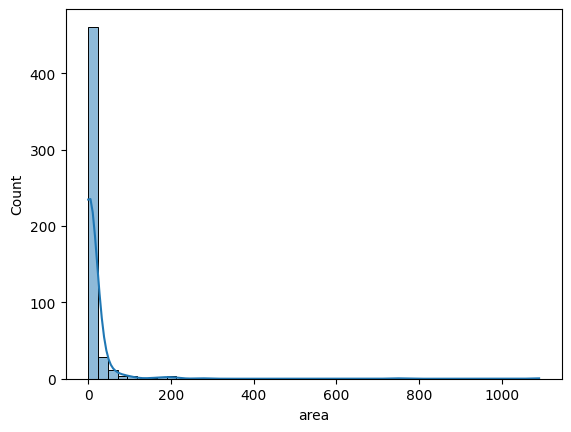

In [14]:
plt.figure()
sns.histplot(df['area'], kde=True)

<Axes: xlabel='temp', ylabel='area'>

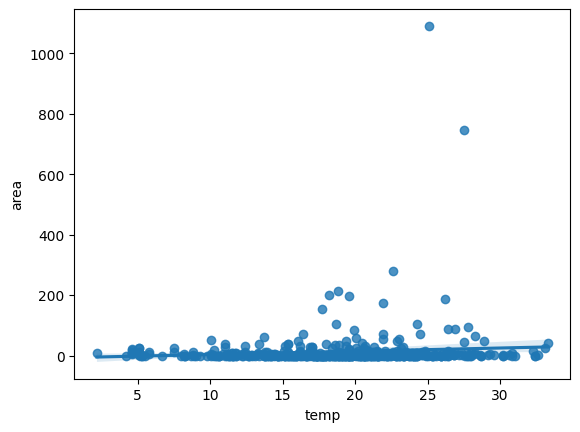

In [15]:
sns.regplot(x="temp", y="area", data=df)

Data insights :
1. area is ours target columns
2. data is non-normal distribution

In [26]:
# Step 3 : preprocess
# Preprocessing Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,RobustScaler

def data_preprocessing():
  X = df.drop(columns='area' )
  y = df['area']

  X_train,X_test,y_train,y_test = train_test_split( X ,y ,
                                                  test_size= 0.30 ,
                                                  random_state= 7 )

  le = LabelEncoder()
  for i in X_train.select_dtypes(include= 'object').columns:
      X_train[i] = le.fit_transform(X_train[i])
      X_test[i] = le.transform(X_test[i])

  # step 4 : Scaling Technique : RobustScaler()
  sc = RobustScaler()
  X_train = sc.fit_transform(X_train)
  X_test = sc.transform(X_test)
  return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test =data_preprocessing()

In [38]:
# # model train
# from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor , GradientBoostingRegressor
# from sklearn.svm import SVC

# def model_train(X_train,X_test,y_train,y_test):
#   models = {
#       'LinearRegression' : LinearRegression(),
#       'DecisionTreeRegressor' : DecisionTreeRegressor(),
#       'RandomForestRegressor' : RandomForestRegressor(),
#       'AdaBoostRegressor' : AdaBoostRegressor(),
#       'GradientBoostingRegressor' : GradientBoostingRegressor(),
#       'svc': SVC()

      
#   }

#   Regression_models  = [ ]

#   for model_name, model in models.items() :
#     # fit the data on train : seen data
#     model.fit(X_train,y_train)
#     # prediction value based on test data: Unseen data
#     y_pred = model.predict(X_test)

#     # Evaluating metrics
#     r2_score_model = r2_score(y_test,y_pred)
#     mse_model = mean_squared_error(y_test,y_pred)
#     mae_model = mean_absolute_error(y_test,y_pred)

#     Regression_models.append({
#         "model name " : model_name ,
#         "R 2 score " : r2_score_model,
#         "Mse" : mse_model,
#         "Mae" : mae_model
#     })

#     models_report = pd.DataFrame(Regression_models)

#   return models_report

# model train
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor , GradientBoostingRegressor

def model_train(X_train,X_test,y_train,y_test):
  models = {
      'LinearRegression' : LinearRegression(),
      'DecisionTreeRegressor' : DecisionTreeRegressor(),
      'RandomForestRegressor' : RandomForestRegressor(),
      'AdaBoostRegressor' : AdaBoostRegressor(),
      'GradientBoostingRegressor' : GradientBoostingRegressor()
      
  }

  Regression_models  = [ ]

  for model_name, model in models.items() :
    # fit the data on train : seen data
    model.fit(X_train,y_train)
    # prediction value based on test data: Unseen data
    y_pred = model.predict(X_test)

    # Evaluating metrics
    r2_score_model = r2_score(y_test,y_pred)
    mse_model = mean_squared_error(y_test,y_pred)
    mae_model = mean_absolute_error(y_test,y_pred)

    Regression_models.append({
        "model name " : model_name ,
        "R 2 score " : r2_score_model,
        "Mse" : mse_model,
        "Mae" : mae_model
    })

    models_report = pd.DataFrame(Regression_models)

  return models_report

In [39]:
models_report = model_train(X_train,X_test,y_train,y_test)

models_report

,model name,R 2 score,Mse,Mae
0,LinearRegression,-0.062644,1443.320067,21.342661
1,DecisionTreeRegressor,-5.948613,9437.845400,29.354006
2,RandomForestRegressor,-1.376774,3228.216240,24.405909
3,AdaBoostRegressor,-1.280997,3098.128526,21.726448
4,GradientBoostingRegressor,-1.265472,3077.042433,20.372323


#### All the R2 Score are in - negative thats why we will use logn method  

### Regression using logn

In [40]:
# Librarys

# Import manipulation librarys
import numpy as np
import pandas as pd

# Import visualization librarys
import matplotlib.pyplot as plt
import seaborn as sns

# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [42]:
# Data Ingestion 
df = pd.read_csv(r'C:\15Days15Project\Forest-Fire-Risk-and-Impact-Prediction-Model\data\raw\forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [43]:
df_reg = df[df["area"] > 0].copy()

<Axes: xlabel='area', ylabel='Count'>

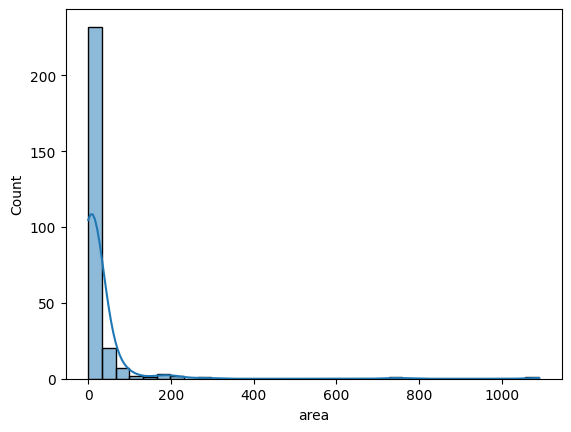

In [44]:
# Before log normal
plt.figure()
sns.histplot(df_reg["area"], kde=True)

In [46]:
df_reg["log_area"] = np.log1p(df_reg["area"])

<Axes: xlabel='log_area', ylabel='Count'>

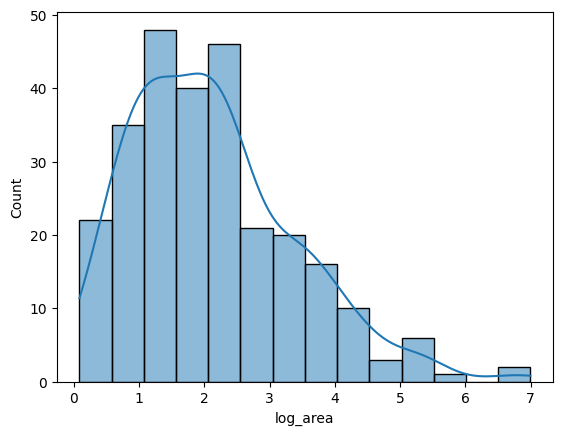

In [47]:
# After Log normal
sns.histplot(df_reg["log_area"], kde=True)

<Axes: xlabel='temp', ylabel='log_area'>

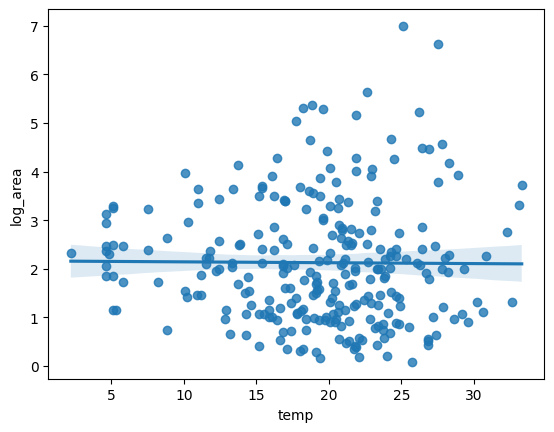

In [48]:
sns.regplot(x="temp", y="log_area", data=df_reg)

In [53]:
# model train
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor , GradientBoostingRegressor
from sklearn.svm import SVC

def model_train(X_train,X_test,y_train,y_test):
  models = {
      'LinearRegression' : LinearRegression(),
      'DecisionTreeRegressor' : DecisionTreeRegressor(),
      'RandomForestRegressor' : RandomForestRegressor(),
      'AdaBoostRegressor' : AdaBoostRegressor(),
      'GradientBoostingRegressor' : GradientBoostingRegressor()
  }

  LinearRegression_models  = [ ]

  for model_name, model in models.items() :
    # fit the data on train : seen data
    model.fit(X_train,y_train)
    # prediction value based on test data: Unseen data
    y_pred = model.predict(X_test)

    # Evaluating metrics
    r2_score_model = r2_score(y_test,y_pred)
    mse_model = mean_squared_error(y_test,y_pred)
    mae_model = mean_absolute_error(y_test,y_pred)

    LinearRegression_models.append({
        "model name " : model_name ,
        "R 2 score " : r2_score_model,
        "Mse" : mse_model,
        "Mae" : mae_model
    })

    models_report = pd.DataFrame(LinearRegression_models)

  return models_report

In [54]:
model_report = model_train(X_train,X_test,y_train,y_test)
model_report

,model name,R 2 score,Mse,Mae
0,LinearRegression,-0.062644,1443.320067,21.342661
1,DecisionTreeRegressor,-3.010591,5447.322566,21.941122
2,RandomForestRegressor,-0.941325,2636.774616,23.234950
3,AdaBoostRegressor,-1.174632,2953.660318,20.139378
4,GradientBoostingRegressor,-1.271453,3085.165867,20.432115


### Final Insights
Direct regression on burned area resulted in highly unstable predictions and strongly negative R2 values.
Applying a log-normal transformation reduced skewness and improved error stability, as reflected by lower MAE, although R2 remained modest due to the inherent unpredictability of extreme fire events.